# Data Exploration - Geo-SLM Chart Analysis V3

**Purpose:** Analyze the collected dataset before YOLO training

**Data Sources:**
- HuggingFace ChartQA: ~20,000 images
- ArXiv Mining: ~5,000 images (estimated)
- Synthetic (optional): Generated charts

**Date:** 2026-01-20

In [7]:
# Standard imports
import json
import sys
from pathlib import Path
from collections import Counter

# Data science
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / 'data'
ACADEMIC_DATASET = DATA_ROOT / 'academic_dataset'

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {DATA_ROOT}")

Project root: d:\elix\chart_analysis_ai_v3
Data root: d:\elix\chart_analysis_ai_v3\data


## 1. Dataset Overview

Count images from each source and display summary statistics.

In [8]:
def count_images_by_source():
    """Count images from different sources."""
    stats = {
        'source': [],
        'count': [],
        'path': []
    }
    
    # HuggingFace ChartQA
    hf_chartqa = ACADEMIC_DATASET / 'images' / 'huggingface' / 'chartqa'
    if hf_chartqa.exists():
        count = len(list(hf_chartqa.glob('*')))
        stats['source'].append('HuggingFace ChartQA')
        stats['count'].append(count)
        stats['path'].append(str(hf_chartqa))
    
    # ArXiv Mined
    arxiv_dir = ACADEMIC_DATASET / 'images'
    if arxiv_dir.exists():
        # Count only direct files (not in subdirs)
        count = len([f for f in arxiv_dir.glob('*.png') if f.parent == arxiv_dir])
        stats['source'].append('ArXiv Mining')
        stats['count'].append(count)
        stats['path'].append(str(arxiv_dir))
    
    # Synthetic (if exists)
    synthetic_count = len([f for f in arxiv_dir.glob('synthetic_*.png')]) if arxiv_dir.exists() else 0
    if synthetic_count > 0:
        stats['source'].append('Synthetic')
        stats['count'].append(synthetic_count)
        stats['path'].append('Generated')
    
    return pd.DataFrame(stats)

# Get counts
df_sources = count_images_by_source()
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(df_sources.to_string(index=False))
print(f"\nTotal Images: {df_sources['count'].sum():,}")
print("=" * 50)

DATASET OVERVIEW
             source  count                                                                          path
HuggingFace ChartQA  20000 d:\elix\chart_analysis_ai_v3\data\academic_dataset\images\huggingface\chartqa
       ArXiv Mining  12839                     d:\elix\chart_analysis_ai_v3\data\academic_dataset\images
          Synthetic    447                                                                     Generated

Total Images: 33,286


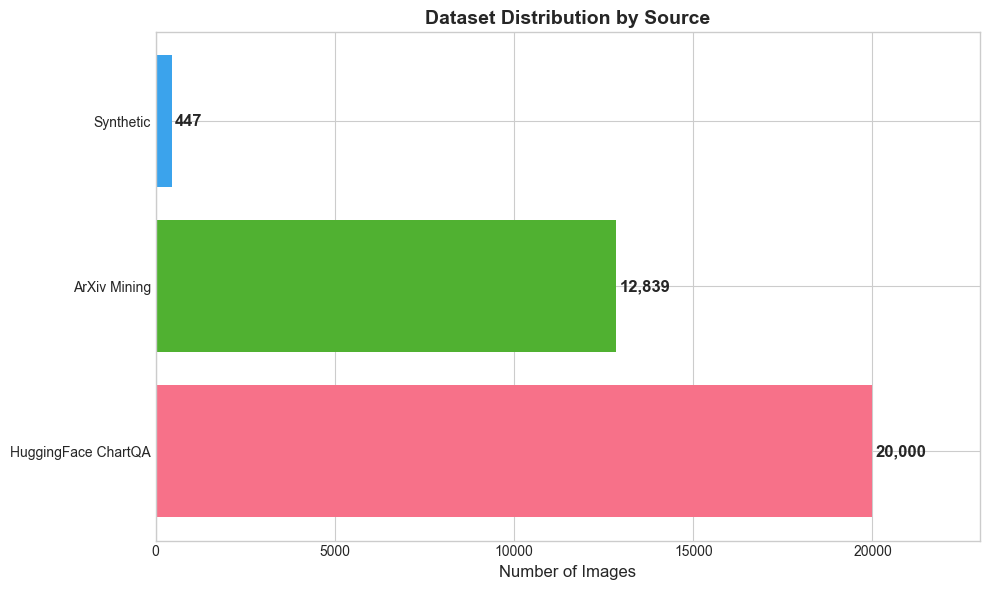

In [9]:
# Visualize distribution
fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette('husl', len(df_sources))
bars = ax.barh(df_sources['source'], df_sources['count'], color=colors)

# Add value labels
for bar, count in zip(bars, df_sources['count']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Number of Images', fontsize=12)
ax.set_title('Dataset Distribution by Source', fontsize=14, fontweight='bold')
ax.set_xlim(0, df_sources['count'].max() * 1.15)

plt.tight_layout()
plt.show()

## 2. Metadata Analysis

Load and analyze metadata from ArXiv mined images.

In [10]:
def load_all_metadata(limit: int = None):
    """Load all metadata JSON files."""
    metadata_dir = ACADEMIC_DATASET / 'metadata'
    
    if not metadata_dir.exists():
        print(f"Metadata directory not found: {metadata_dir}")
        return []
    
    json_files = list(metadata_dir.glob('*.json'))
    if limit:
        json_files = json_files[:limit]
    
    metadata_list = []
    for json_path in json_files:
        try:
            with open(json_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                data['_file'] = json_path.name
                metadata_list.append(data)
        except Exception as e:
            continue
    
    return metadata_list

# Load metadata
metadata = load_all_metadata()
print(f"Loaded {len(metadata):,} metadata files")

if metadata:
    df_meta = pd.DataFrame(metadata)
    print(f"\nColumns: {list(df_meta.columns)}")

Loaded 12,805 metadata files

Columns: ['image_id', 'source', 'parent_paper_id', 'source_url', 'page_number', 'image_path', 'thumbnail_path', 'width', 'height', 'file_size_bytes', 'format', 'chart_type', 'caption_text', 'context_text', 'bbox', 'is_valid', 'quality_score', 'validation_notes', 'extracted_at', 'aspect_ratio', '_file']


In [11]:
# Analyze caption quality
if metadata:
    caption_stats = {
        'has_caption': 0,
        'empty_caption': 0,
        'has_context': 0,
        'caption_lengths': []
    }
    
    for item in metadata:
        caption = item.get('caption_text', '')
        context = item.get('context_text', '')
        
        if caption and len(caption.strip()) > 0:
            caption_stats['has_caption'] += 1
            caption_stats['caption_lengths'].append(len(caption))
        else:
            caption_stats['empty_caption'] += 1
        
        if context and len(context.strip()) > 0:
            caption_stats['has_context'] += 1
    
    total = len(metadata)
    print("=" * 50)
    print("CAPTION QUALITY ANALYSIS")
    print("=" * 50)
    print(f"Total metadata files: {total:,}")
    print(f"Has caption: {caption_stats['has_caption']:,} ({100*caption_stats['has_caption']/total:.1f}%)")
    print(f"Empty caption: {caption_stats['empty_caption']:,} ({100*caption_stats['empty_caption']/total:.1f}%)")
    print(f"Has context: {caption_stats['has_context']:,} ({100*caption_stats['has_context']/total:.1f}%)")
    
    if caption_stats['caption_lengths']:
        print(f"\nCaption length stats:")
        print(f"  Min: {min(caption_stats['caption_lengths'])} chars")
        print(f"  Max: {max(caption_stats['caption_lengths'])} chars")
        print(f"  Mean: {np.mean(caption_stats['caption_lengths']):.0f} chars")
    print("=" * 50)

CAPTION QUALITY ANALYSIS
Total metadata files: 12,805
Has caption: 11,831 (92.4%)
Empty caption: 974 (7.6%)
Has context: 9,804 (76.6%)

Caption length stats:
  Min: 1 chars
  Max: 3070 chars
  Mean: 167 chars


## 3. Image Size Distribution

Analyze image dimensions to determine optimal YOLO input size.

In [12]:
def analyze_image_sizes(sample_size: int = 500):
    """Analyze image dimensions from a sample."""
    images_dir = ACADEMIC_DATASET / 'images'
    
    # Collect image paths
    all_images = []
    
    # ArXiv images
    all_images.extend([f for f in images_dir.glob('*.png') if f.parent == images_dir])
    
    # ChartQA images
    chartqa_dir = images_dir / 'huggingface' / 'chartqa'
    if chartqa_dir.exists():
        all_images.extend(list(chartqa_dir.glob('*'))[:sample_size])
    
    # Sample
    if len(all_images) > sample_size:
        import random
        random.seed(42)
        all_images = random.sample(all_images, sample_size)
    
    sizes = []
    for img_path in all_images:
        try:
            with Image.open(img_path) as img:
                sizes.append({
                    'width': img.width,
                    'height': img.height,
                    'aspect_ratio': img.width / img.height,
                    'source': 'ChartQA' if 'chartqa' in str(img_path) else 'ArXiv'
                })
        except Exception:
            continue
    
    return pd.DataFrame(sizes)

print("Analyzing image sizes (sampling 500 images)...")
df_sizes = analyze_image_sizes(500)
print(f"Analyzed {len(df_sizes)} images")

Analyzing image sizes (sampling 500 images)...


d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (134852700 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Analyzed 500 images


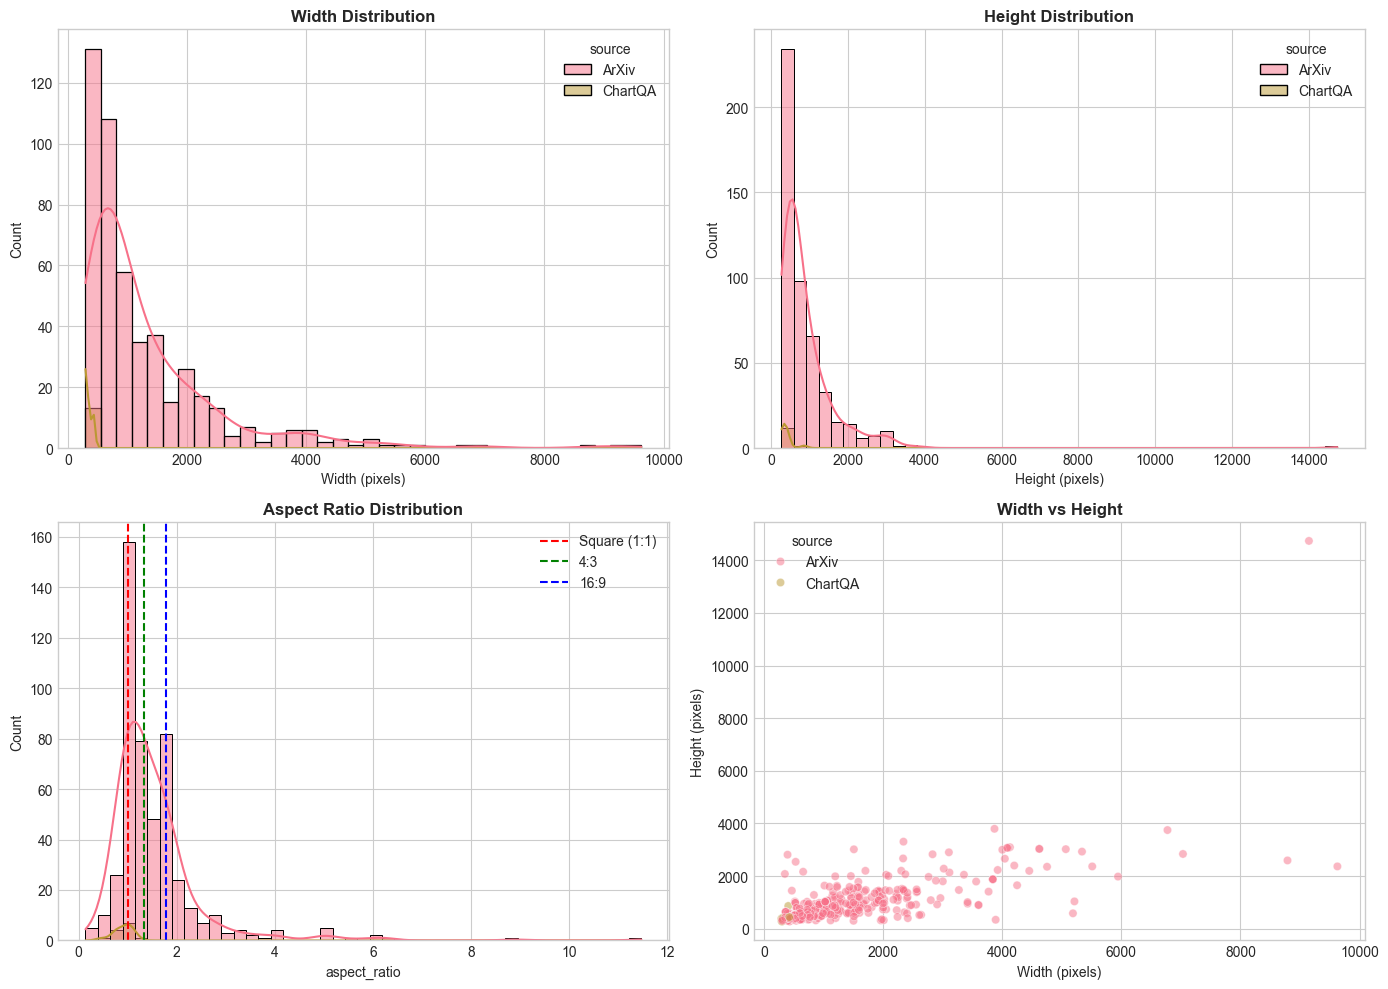


IMAGE SIZE STATISTICS
        width   height  aspect_ratio
count   500.0    500.0         500.0
mean   1283.6    884.0           1.5
std    1234.6    883.9           1.0
min     290.0    276.0           0.1
25%     512.0    467.0           1.0
50%     800.0    600.0           1.3
75%    1570.0   1024.0           1.8
max    9628.0  14738.0          11.5


In [13]:
if len(df_sizes) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Width distribution
    ax1 = axes[0, 0]
    sns.histplot(data=df_sizes, x='width', hue='source', kde=True, ax=ax1)
    ax1.set_title('Width Distribution', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Width (pixels)')
    
    # Height distribution
    ax2 = axes[0, 1]
    sns.histplot(data=df_sizes, x='height', hue='source', kde=True, ax=ax2)
    ax2.set_title('Height Distribution', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Height (pixels)')
    
    # Aspect ratio
    ax3 = axes[1, 0]
    sns.histplot(data=df_sizes, x='aspect_ratio', hue='source', kde=True, ax=ax3)
    ax3.axvline(x=1.0, color='red', linestyle='--', label='Square (1:1)')
    ax3.axvline(x=4/3, color='green', linestyle='--', label='4:3')
    ax3.axvline(x=16/9, color='blue', linestyle='--', label='16:9')
    ax3.set_title('Aspect Ratio Distribution', fontsize=12, fontweight='bold')
    ax3.legend()
    
    # Width vs Height scatter
    ax4 = axes[1, 1]
    sns.scatterplot(data=df_sizes, x='width', y='height', hue='source', alpha=0.5, ax=ax4)
    ax4.set_title('Width vs Height', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Width (pixels)')
    ax4.set_ylabel('Height (pixels)')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "=" * 50)
    print("IMAGE SIZE STATISTICS")
    print("=" * 50)
    print(df_sizes[['width', 'height', 'aspect_ratio']].describe().round(1))
    print("=" * 50)

## 4. Sample Images Preview

Display random sample images from each source.

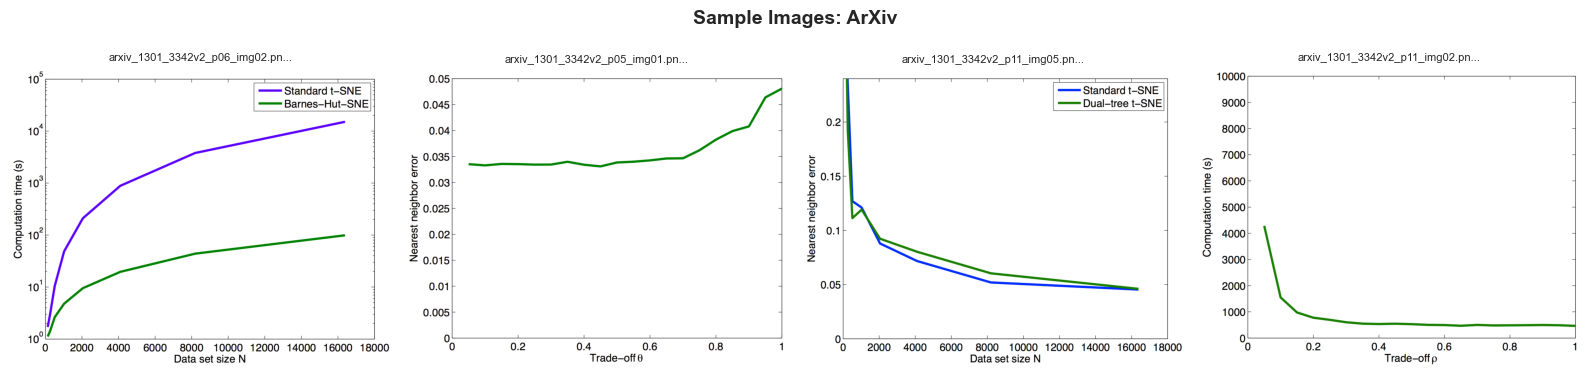

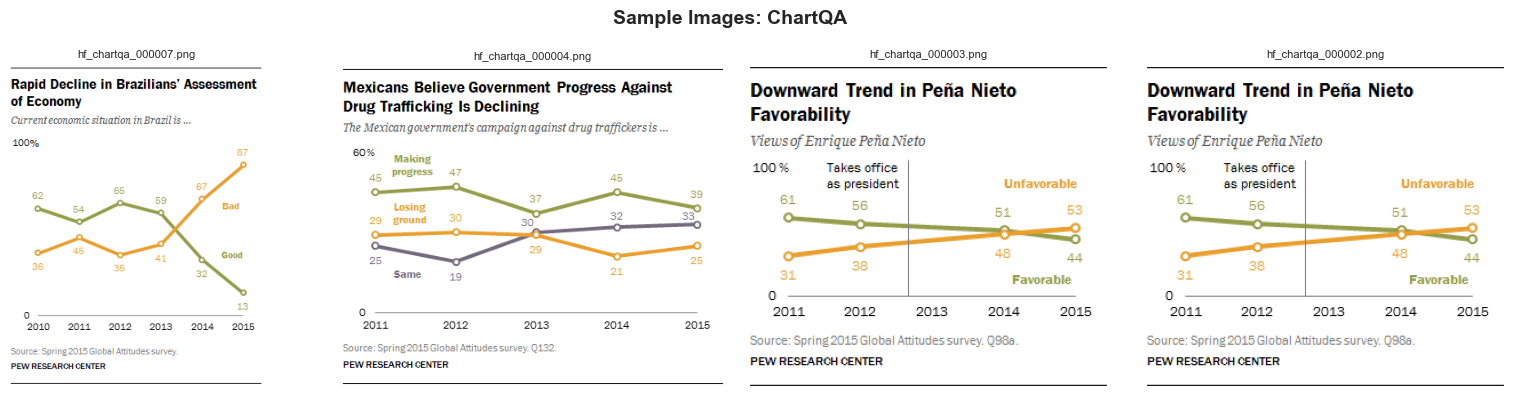

In [14]:
def show_sample_images(n_samples: int = 4):
    """Display sample images from each source."""
    import random
    random.seed(42)
    
    images_dir = ACADEMIC_DATASET / 'images'
    
    # Collect samples
    arxiv_images = [f for f in images_dir.glob('arxiv_*.png')][:20]
    chartqa_dir = images_dir / 'huggingface' / 'chartqa'
    chartqa_images = list(chartqa_dir.glob('*'))[:20] if chartqa_dir.exists() else []
    
    samples = {
        'ArXiv': random.sample(arxiv_images, min(n_samples, len(arxiv_images))) if arxiv_images else [],
        'ChartQA': random.sample(chartqa_images, min(n_samples, len(chartqa_images))) if chartqa_images else []
    }
    
    for source, paths in samples.items():
        if not paths:
            continue
            
        fig, axes = plt.subplots(1, len(paths), figsize=(4*len(paths), 4))
        if len(paths) == 1:
            axes = [axes]
        
        fig.suptitle(f'Sample Images: {source}', fontsize=14, fontweight='bold')
        
        for ax, img_path in zip(axes, paths):
            try:
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(img_path.name[:30] + '...' if len(img_path.name) > 30 else img_path.name,
                            fontsize=8)
                ax.axis('off')
            except Exception as e:
                ax.text(0.5, 0.5, f'Error: {e}', ha='center')
                ax.axis('off')
        
        plt.tight_layout()
        plt.show()

show_sample_images(4)

## 5. Caption Word Cloud

Visualize common words in chart captions.

In [15]:
# Note: Requires wordcloud package
# pip install wordcloud

try:
    from wordcloud import WordCloud
    
    if metadata:
        # Combine all captions
        all_captions = ' '.join([
            item.get('caption_text', '') 
            for item in metadata 
            if item.get('caption_text')
        ])
        
        if all_captions.strip():
            # Generate word cloud
            wordcloud = WordCloud(
                width=1200, 
                height=600,
                background_color='white',
                colormap='viridis',
                max_words=100,
                min_font_size=10
            ).generate(all_captions)
            
            plt.figure(figsize=(14, 7))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.axis('off')
            plt.title('Word Cloud of Chart Captions', fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()
        else:
            print("No captions available for word cloud")
    else:
        print("No metadata loaded")
        
except ImportError:
    print("WordCloud not installed. Run: pip install wordcloud")

WordCloud not installed. Run: pip install wordcloud


## 6. Summary & Recommendations

Based on the analysis above, here are the recommendations for YOLO training:

In [16]:
print("=" * 60)
print("SUMMARY & RECOMMENDATIONS FOR YOLO TRAINING")
print("=" * 60)

if len(df_sizes) > 0:
    median_width = df_sizes['width'].median()
    median_height = df_sizes['height'].median()
    
    # Recommend image size
    if median_width > 800 or median_height > 800:
        recommended_size = 640
    else:
        recommended_size = 416
    
    print(f"\n1. IMAGE SIZE:")
    print(f"   Median dimensions: {median_width:.0f} x {median_height:.0f}")
    print(f"   Recommended YOLO imgsz: {recommended_size}")

print(f"\n2. DATASET SPLIT (80/10/10):")
total = df_sources['count'].sum() if len(df_sources) > 0 else 0
print(f"   Total images: {total:,}")
print(f"   Train: ~{int(total * 0.8):,} images")
print(f"   Val: ~{int(total * 0.1):,} images")
print(f"   Test: ~{int(total * 0.1):,} images")

print(f"\n3. TRAINING RECOMMENDATIONS:")
print(f"   - Model: YOLOv8n (nano) for fast iteration")
print(f"   - Epochs: 100-200")
print(f"   - Batch size: 16-32 (depending on GPU)")
print(f"   - Augmentation: Disable flip, reduce rotation")

print(f"\n4. NEXT STEPS:")
print(f"   a. Run: python scripts/prepare_dataset_splits.py")
print(f"   b. Annotate with bounding boxes (LabelImg/CVAT)")
print(f"   c. Train: yolo train model=yolov8n.pt data=config/yolo_chart_v3.yaml")
print("=" * 60)

SUMMARY & RECOMMENDATIONS FOR YOLO TRAINING

1. IMAGE SIZE:
   Median dimensions: 800 x 600
   Recommended YOLO imgsz: 416

2. DATASET SPLIT (80/10/10):
   Total images: 33,286
   Train: ~26,628 images
   Val: ~3,328 images
   Test: ~3,328 images

3. TRAINING RECOMMENDATIONS:
   - Model: YOLOv8n (nano) for fast iteration
   - Epochs: 100-200
   - Batch size: 16-32 (depending on GPU)
   - Augmentation: Disable flip, reduce rotation

4. NEXT STEPS:
   a. Run: python scripts/prepare_dataset_splits.py
   b. Annotate with bounding boxes (LabelImg/CVAT)
   c. Train: yolo train model=yolov8n.pt data=config/yolo_chart_v3.yaml
